In [1]:
words = open("../data/names.txt","r").read().splitlines()

In [2]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    # sliding
    for ch1, ch2 in zip(chs, chs[1:]):
        bigrams = (ch1,ch2)
        b[bigrams] = b.get(bigrams,0)+1
        

In [3]:
sorted(b.items(), key= lambda x:x[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [4]:
import torch


In [5]:
N = torch.zeros((27,27),dtype=torch.int32)


In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}


In [7]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    # sliding
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline


(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

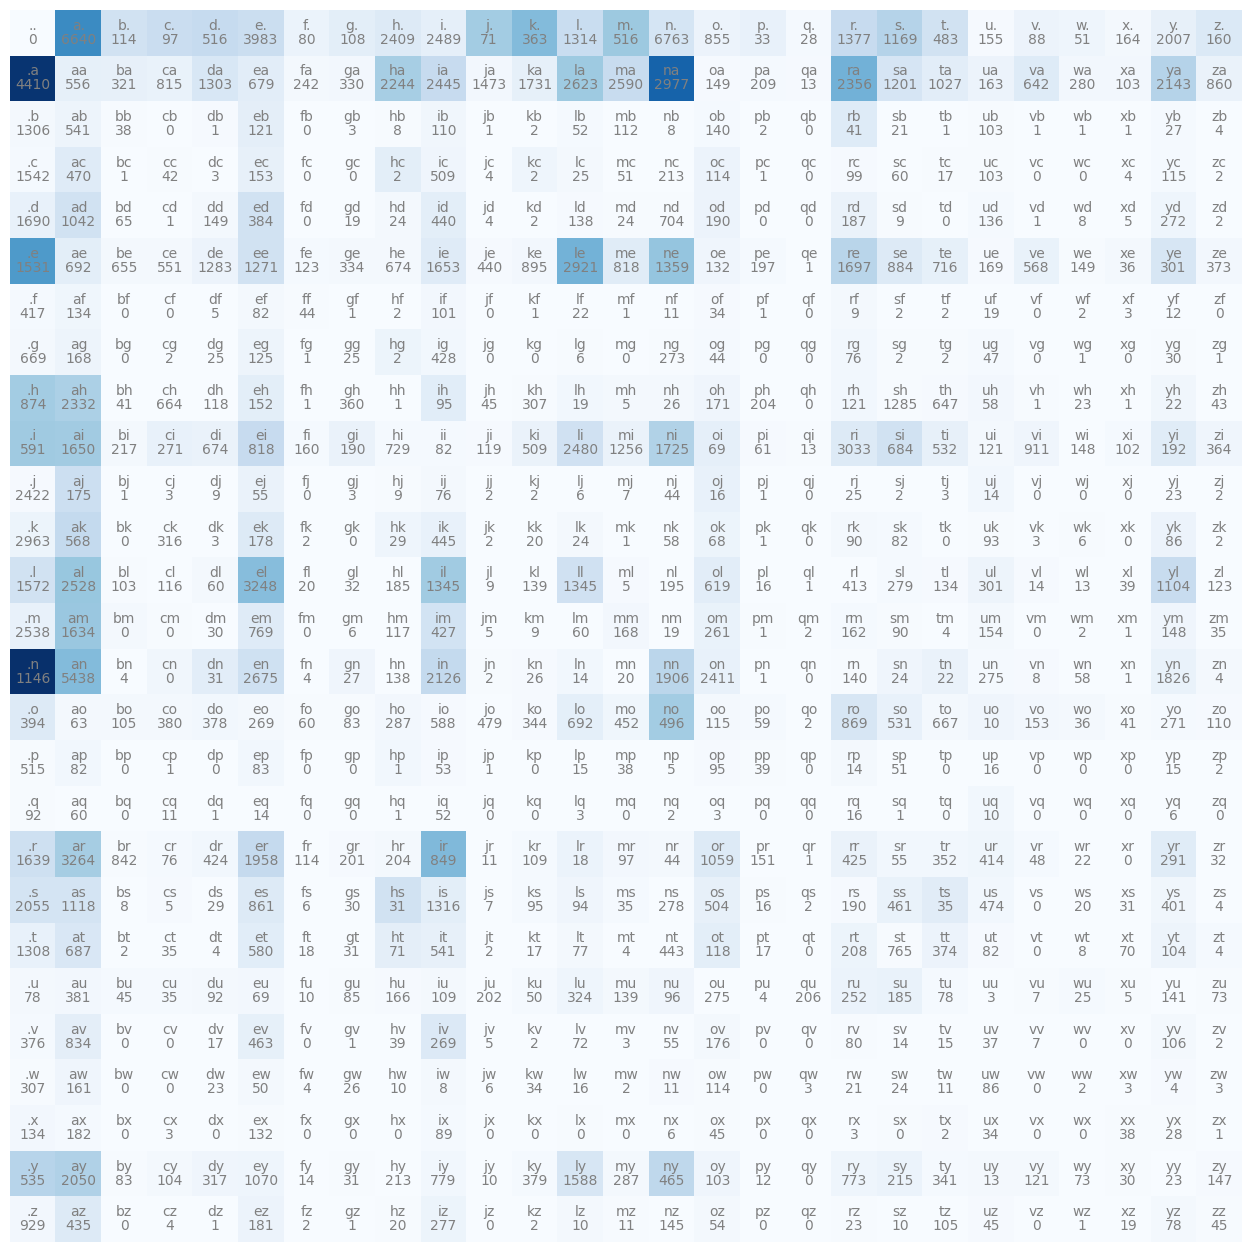

In [9]:
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(i,j,chstr,ha='center', va ="bottom",color="gray")
        plt.text(i,j,N[i,j].item(),ha="center", va="top", color="gray")
plt.axis("off")

In [10]:
N[0,:]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [11]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [12]:
g = torch.Generator().manual_seed(43)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix
itos[ix]


'r'

In [13]:
torch.multinomial(p, num_samples = 100, replacement=True, generator=g)

tensor([ 4,  5,  3, 11, 10,  1,  5,  8, 23, 26, 14,  1, 11, 19, 13, 11, 12, 16,
         7, 11, 14,  3, 19, 17, 11,  4,  4, 19, 11, 10,  4,  8, 26,  1, 19, 13,
        12, 10, 12, 20,  5, 10, 10, 10, 10, 10, 19, 20, 10, 12, 19, 11, 13, 10,
         2,  6, 11, 14, 19, 11, 12, 10, 20,  1, 12, 10,  4,  5,  3,  5,  6, 20,
        11, 13, 15, 11,  3,  2,  7,  5,  1, 18,  8,  1,  7,  4, 14,  5,  1,  2,
        12, 13, 13, 13,  4, 13,  5, 25,  1,  1])

In [23]:
P = (N+2).float()
P.sum(dim=1,keepdim=True).shape

torch.Size([27, 1])

Broadcasting
Either all dimensions must be equal
Either the dimension is 1 or 
Either the dimension does not exist

In [24]:
P /= P.sum(dim=1,keepdim=True)

In [25]:
g = torch.Generator().manual_seed(43)
for i in range(20):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print("".join(out))


ren.
roinyaclynenelazar.
lentobaien.
kiah.
kosa.
gaf.
jerinirumuaydowon.
jea.
mber.
r.
zorl.
silioplylonawrifma.
caciowelen.
yn.
mi.
ly.
ndeik.
pera.
asansylain.
e.


In [26]:
log_likelihood = 0.0
n = 0
for w in ["achiketk"]:
    chs = ['.']+ list(w)+ ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob= torch.log(prob)
        log_likelihood += logprob
        n+=1
         

print(f"{log_likelihood}")
nll = -log_likelihood
print(-log_likelihood/n)

-29.85041046142578
tensor(3.3167)


In [100]:
# Create a training set of all the bigrams
xs, ys  = [],[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
num

228146

In [53]:
xs,ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [101]:
import torch.nn.functional as F


In [140]:
g = torch.Generator().manual_seed(42)
w = torch.randn(size=(27,27),generator=g, requires_grad=True)


In [ ]:
# xenc = F.one_hot(xs, num_classes=27).float()
# logits = (xenc @w ) # log cnts
# counts  = logits.exp()
# # equivalent to N matrix
# prob = counts/counts.sum(1, keepdim=True)
# loss =-prob[torch.arange(5), ys].log().mean()



In [97]:
# loss

tensor(4.3679, grad_fn=<NegBackward0>)

In [ ]:
#  backward pass
# w.grad =None
# loss.backward()

In [138]:
# # update
# lr = 0.01
# w.data += -lr * w.grad
w=w+1

In [141]:
for i in range(1000):
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = (xenc @w ) # log cnts
    counts  = logits.exp()
    # equivalent to N matrix
    prob = counts/counts.sum(1, keepdim=True)
    loss =-prob[torch.arange(num), ys].log().mean() + 0.01 * (w**2).mean()
    print("LOSS: " , loss)
    #  backward pass
    w.grad =None
    loss.backward()

    # update
    lr = 0.01 * i* (1/10)
    w.data += -lr * w.grad



LOSS:  tensor(3.7065, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7065, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7065, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7065, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7064, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7064, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7064, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7063, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7063, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7062, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7061, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7061, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7060, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7059, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7058, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7057, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7056, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7054, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7053, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7052, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7050, grad_fn=<AddBackward0>)
LOSS:  tensor(3.7049, grad_fn=<Add

In [120]:
w.exp()

tensor([[ 0.4502,  5.8112,  1.7001,  1.5922,  2.1851,  1.8024,  0.6254,  0.5536,
          0.9893,  0.9201,  3.1398,  3.8578,  1.9386,  3.2941,  1.3376,  0.6893,
          0.8472,  0.3624,  2.0561,  2.6624,  1.5623,  0.4648,  0.6764,  0.6655,
          0.5149,  0.8519,  1.2296],
        [ 8.2052,  0.6833,  0.7030,  0.6035,  1.2818,  0.6030,  0.2786,  0.3794,
          2.8405,  1.9807,  0.3598,  0.7549,  3.0613,  1.7812,  6.7076,  0.2415,
          0.2843,  0.1939,  3.9988,  1.1307,  0.7735,  0.4298,  0.9021,  0.4073,
          0.4610,  2.4559,  0.6965],
        [ 0.5555,  1.0074,  0.2615,  0.8951,  0.9625,  6.1360,  0.7949,  3.1900,
          0.3249,  3.8606,  2.5624,  1.7240,  4.5695,  1.3369,  1.1708,  0.9464,
          0.3305,  2.3043,  5.3028,  1.3633,  0.9133,  1.3780,  1.3926,  0.4866,
          0.1082,  0.5441,  0.8737],
        [ 0.7555,  1.8224,  0.4837,  1.2815,  1.1608,  4.5875,  0.8188,  1.3447,
          2.4667,  0.6320,  1.2301,  0.3850,  0.5224,  1.8694,  1.1258,  0.2154

In [142]:
P = w.exp()
w.dtype
for i in range(20):
    g = torch.Generator().manual_seed(i)
    for i in range(20):
        out = []
        ix = 0
        while True:
            p =P[ix]
            ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            out.append(itos[ix])
            if ix == 0:
                break

        print("".join(out))

kedle.
flenakayxaderynvelelyler.
riopmiefwujuswmiella.
kan.
cekhcqqrilexa.
m.
cyccen.
jrm.
jeshqqjqeshridzpeanzenqqndyaga.
jami.
ohayntl.
ynuchyarijixxza.
amabkus.
kaynalah.
dbjjqpdqetebkucmane.
jhfkyamialyaha.
mande.
kembe.
cez.
brarybliara.
anz.
e.
gllma.
ay.
h.
jxuoresjmtezabgmartti.
rielccylenn.
mislaisiyzanja.
dyaelilonalalpxxsh.
ds.
mjpas.
tupmann.
afl.
tte.
kariefgjok.
a.
kl.
bqsaka.
an.
aainusxceleejhar.
an.
zan.
an.
drvzerhacmoougme.
an.
mpxxmien.
mwpbelonan.
xvzyacmienmonirifhaygfa.
eblhiekjje.
.
zqdan.
an.
an.
ke.
a.
abpwun.
nakab.
son.
an.
.
selda.
abacsaa.
araoh.
teremiwsiee.
jtn.
ahnqubjaqwteman.
jz.
kyaycelicqs.
earv.
kihdy.
anarirbmpxxma.
sacrara.
man.
jkanzhavie.
dauoglakan.
hftyncrhwk.
nnzma.
cchiralearelyoe.
kkai.
detzimahcjzqv.
m.
sbdhfzx.
pywnpwpmitkaszusgoxmah.
nubeogkbk.
alkia.
jaivartels.
lamh.
ypbklmi.
rjotxqer.
ltreallvah.
aotysazri.
m.
ukeruunmudauarjmdaranfhne.
angel.
sfalkiahiyaae.
s.
aparepndyqjnkzkalarya.
vin.
de.
llikan.
vtxmamhiyari.
zasxxxxqri.
arvyi.


## MLP

In [148]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [319]:
words = open("../data/names.txt","r").read().splitlines()

In [320]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+ 1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [274]:
block_size = 3 # context length how many characters do we take to predict the next one
X,y  = [], []

for w in words:
    context = [0] * block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        context = context[1:]+[ix]
    
X=torch.tensor(X)
y = torch.tensor(y)

In [328]:
def build_dataset(words:list):
    block_size = 3 # context length how many characters do we take to predict the next one
    X,y  = [], []

    for w in words:
        context = [0] * block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            context = context[1:]+[ix]
        
    X=torch.tensor(X)
    y = torch.tensor(y) 
    return X,y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int (0.9*len(words))  
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])


torch.Size([228146, 3, 2])

In [353]:
# Parameters Initialization
# Lookup Table
g = torch.Generator().manual_seed(42)
C = torch.randn(size=(27,10) , generator=g)
emb = C[Xtr]
w1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)

# torch.cat(torch.unbind(emb,1),1) creates new memory
# more efficient
h = torch.tanh(emb.view(-1,30) @ w1 + b1) 
w2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1,b1, w2, b2]
sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True


In [354]:
sum(p.nelement() for p in parameters)

11897

In [189]:
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), y].log().mean()
# Efficient backward pass/ forward pass and more positive -> inf value , so it subtracts the max value to make it under the range
loss=F.cross_entropy(logits, y)


tensor(17.3284)

In [ ]:

# # No Batching
# for _ in range(200):
#     emb = C[X] # 228146 x3 x2
#     # forward pas
#     h = torch.tanh(emb.view(-1,6)@ w1 +b1) # 32 x 100
#     logits = h @ w2 + b2 # 32 x 27
#     loss = F.cross_entropy(logits, y)
    
#     #  backward pass
#     for p in parameters:
#         p.grad=None
#     loss.backward()

#     for p in parameters:
#         p.data += -0.1 * p.grad
# print(loss.item())


In [355]:
lri = []
lossi = []
stepi = []

In [366]:
# Batching
# torch.randint(0,5,(32,))
# history 

for i in range(100000):
    ix = torch.randint(0,Xtr.shape[0],(32,)) # due to batching
    emb = C[Xtr[ix]] # X.shape[0] x3 x2
    # forward pass
    h = torch.tanh(emb.view(-1,30)@ w1 +b1) # 32 x 100
    logits = h @ w2 + b2 # 32 x 27
    loss = F.cross_entropy(logits, Ytr[ix])
    
    #  backward pass
    for p in parameters:
        p.grad=None
    loss.backward()


    lr = 0.0001
    for p in parameters:
        p.data += -lr * p.grad

    # # track stats 
    lossi.append(loss.log10().item())
    stepi.append(i)

emb = C[Xdev] # shape[0] x3 x2
    # forward pas
h = torch.tanh(emb.view(-1,30)@ w1 +b1) # shape[0] x 100
logits = h @ w2 + b2 # shape[0] x 27
loss = F.cross_entropy(logits, Ydev)
print(loss)

tensor(2.1815, grad_fn=<NllLossBackward0>)


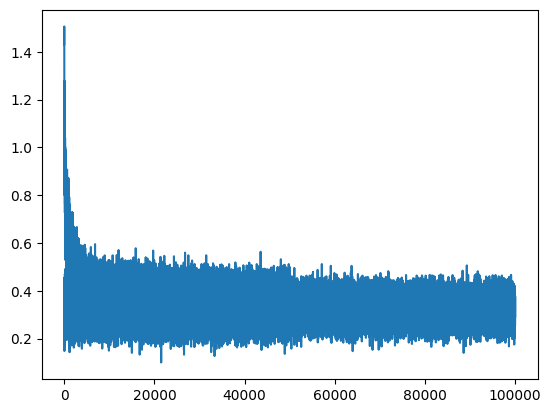

In [367]:
plt.plot(stepi, lossi)

In [368]:
emb = C[Xte] # 32 x3 x2
    # forward pas
h = torch.tanh(emb.view(-1,30)@ w1 +b1) # 32 x 100
logits = h @ w2 + b2 # 32 x 27
loss = F.cross_entropy(logits, Yte)
print(loss)

tensor(2.1784, grad_fn=<NllLossBackward0>)


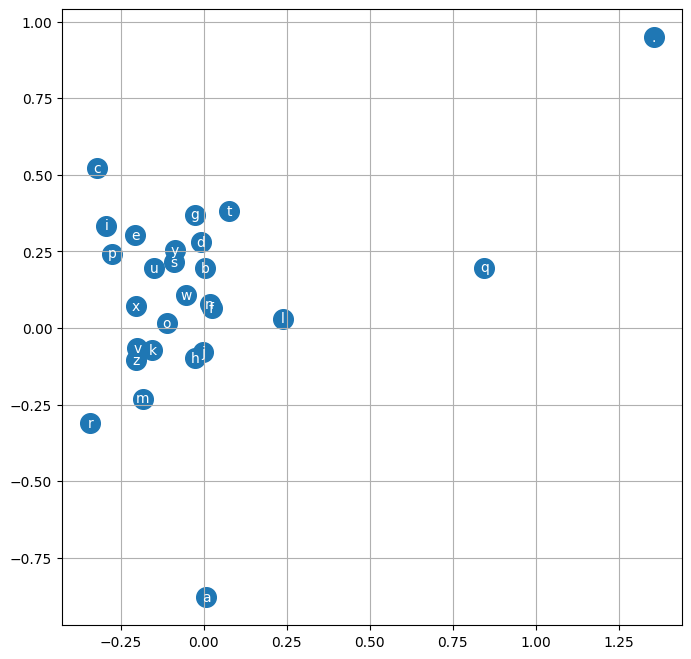

In [365]:
# visualize the embeddings
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data, s =200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i], ha="center", va="center",color="white")
plt.grid("minor")

In [370]:
# Sampling
g = torch.Generator().manual_seed(42)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ w1+b1)
        logits = h@w2 +b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] +[ix]
        out.append(ix)
        if ix ==0: break
    print("".join(itos[i] for i in out))

anuhien.
tis.
marian.
dan.
shan.
silayley.
kemah.
luvan.
emicchulli.
diza.
kence.
jordin.
kalla.
mikolynn.
acvisia.
achalani.
nar.
tihan.
mar.
tal.
